In [1]:
# Code for reproducing wedges results in the paper Sanchez et al. 2016 
# "The clustering of galaxies in the completed SDSS-III Baryon Oscillation Spectroscopic Survey: 
# cosmological implications of the configuration-space clustering wedges"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

In [3]:
# Reading data from the BOSS DR12 wedge files
file_path_1_1 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin1_correlation_function_3wedges1_pre_recon.dat'
file_path_1_2 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin1_correlation_function_3wedges2_pre_recon.dat'
file_path_1_3 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin1_correlation_function_3wedges3_pre_recon.dat'

# File name are swapped in the papaer git repository for BIN 2 and BIN 3
file_path_2_1 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin3_correlation_function_3wedges1_pre_recon.dat'
file_path_2_2 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin3_correlation_function_3wedges2_pre_recon.dat'
file_path_2_3 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin3_correlation_function_3wedges3_pre_recon.dat'

file_path_3_1 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin2_correlation_function_3wedges1_pre_recon.dat'
file_path_3_2 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin2_correlation_function_3wedges2_pre_recon.dat'
file_path_3_3 = './Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin2_correlation_function_3wedges3_pre_recon.dat'

In [4]:
# Getting an idea of the file structure, this operation will be carried for one file only
with open(file_path_1_1, 'r') as file:
    data = file.readlines()

# Printing the first 10 lines of the file
for line in data[:10]:
    print(line.strip())

#measurements of the pre-reconstruction configuration-space 3-wedges of the DR12 combined sample for 0.2 < z < 0.5
#from Sanchez et al. (2016)
#   s/(Mpc/h)          xi_3w,1       sigma xi_3w,1
0.250000000E+01   0.508129515E+01   0.335487226E-01
0.750000000E+01   0.175477649E+01   0.128133800E-01
0.125000000E+02   0.811639460E+00   0.853051586E-02
0.175000000E+02   0.450209654E+00   0.626564463E-02
0.225000000E+02   0.274348311E+00   0.502706081E-02
0.275000000E+02   0.183417946E+00   0.419071252E-02
0.325000000E+02   0.126147337E+00   0.366328175E-02


In [5]:
# Reading the file with pandas
df_1_1 = pd.read_csv(file_path_1_1, sep='\s+', skiprows=3, header=None)

# Manual column naming
df_1_1.columns = ['s_Mpc_h', 'xi_3w_1', 'sigma_xi_3w_1']

# Visualize the first few rows of the DataFrame
print(df_1_1.head())

# Check the shape of the DataFrame
print(df_1_1.shape)

# Check the column names
print(df_1_1.columns)

   s_Mpc_h   xi_3w_1  sigma_xi_3w_1
0      2.5  5.081295       0.033549
1      7.5  1.754776       0.012813
2     12.5  0.811639       0.008531
3     17.5  0.450210       0.006266
4     22.5  0.274348       0.005027
(32, 3)
Index(['s_Mpc_h', 'xi_3w_1', 'sigma_xi_3w_1'], dtype='object')


In [6]:
# Reading the files with pandas
df_1_2 = pd.read_csv(file_path_1_2, sep='\s+', skiprows=3, header=None)
df_1_3 = pd.read_csv(file_path_1_3, sep='\s+', skiprows=3, header=None)

df_2_1 = pd.read_csv(file_path_2_1, sep='\s+', skiprows=3, header=None)
df_2_2 = pd.read_csv(file_path_2_2, sep='\s+', skiprows=3, header=None)
df_2_3 = pd.read_csv(file_path_2_3, sep='\s+', skiprows=3, header=None)

df_3_1 = pd.read_csv(file_path_3_1, sep='\s+', skiprows=3, header=None)
df_3_2 = pd.read_csv(file_path_3_2, sep='\s+', skiprows=3, header=None)
df_3_3 = pd.read_csv(file_path_3_3, sep='\s+', skiprows=3, header=None)

# Manual column naming
df_1_2.columns = ['s_Mpc_h', 'xi_3w_2', 'sigma_xi_3w_2']
df_1_3.columns = ['s_Mpc_h', 'xi_3w_3', 'sigma_xi_3w_3']

df_2_1.columns = ['s_Mpc_h', 'xi_3w_1', 'sigma_xi_3w_1']
df_2_2.columns = ['s_Mpc_h', 'xi_3w_2', 'sigma_xi_3w_2']
df_2_3.columns = ['s_Mpc_h', 'xi_3w_3', 'sigma_xi_3w_3']

df_3_1.columns = ['s_Mpc_h', 'xi_3w_1', 'sigma_xi_3w_1']
df_3_2.columns = ['s_Mpc_h', 'xi_3w_2', 'sigma_xi_3w_2']
df_3_3.columns = ['s_Mpc_h', 'xi_3w_3', 'sigma_xi_3w_3']


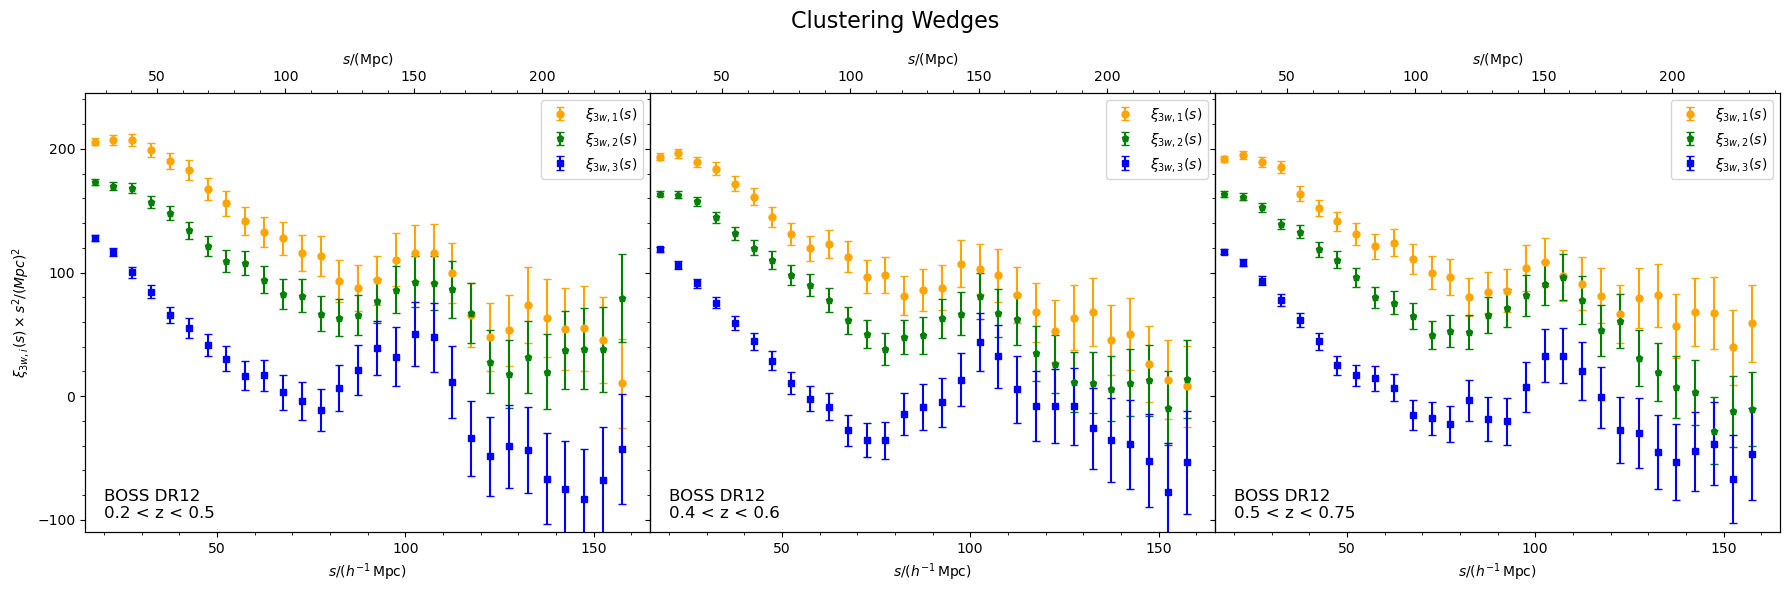

In [7]:
# Wedges plot
dataframes = [df_1_1, df_1_2, df_1_3, df_2_1, df_2_2, df_2_3, df_3_1, df_3_2, df_3_3]

# Layout of 1 row and 3 columns for the plot
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True, gridspec_kw={'wspace': 0, 'width_ratios': [1, 1, 1]})
# sharey=True allows to share the y-axis among the subplots

# General title
fig.suptitle("Clustering Wedges", fontsize=16)

# Colors, labels and z_ranges
colors = ['orange', 'green', 'blue']
labels = [r'$\xi_{3w,1}(s)$', r'$\xi_{3w,2}(s)$', r'$\xi_{3w,3}(s)$']
z_ranges = ["0.2 < z < 0.5", "0.4 < z < 0.6", "0.5 < z < 0.75"]

# Assuming a value for the reduced Hubble parameter h to convert the x-axis values
h = 0.67

# Iterate over the subplots (one for each redshift range)
for i, ax in enumerate(axs):
    # Plot of the 3 DataFrame for each subplot
    for j in range(3):
        # Obtain the corrspondent DataFrame
        df = dataframes[i * 3 + j]
        
        # Assign data (column 1: x, column 2: y, column 3: error over y)
        x = df.iloc[:, 0]
        y = df.iloc[:, 1]
        yerr = df.iloc[:, 2]
        
        # Plot with error bars
        ax.errorbar(x, y*x**2/h, yerr=yerr*x**2/h, fmt='o' if colors[j] == 'orange' else 's' if colors[j] == 'blue' else 'p', color=colors[j], label=labels[j], markersize=5, capsize=3)


    
    # y-axis
    ax.set_ylim(-110, 245)  
    ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    axs[0].set_ylabel(r"$\xi_{3w,i}(s) \times s^2/(Mpc)^2$")

    # Major and minor ticks on lower x-axis    
    ax.set_xlim(15, 165) 
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.set_xlabel(r"$s/(h^{-1} \, \mathrm{Mpc})$")

    # Top axis
    ax_top = ax.twiny()
    ax_top.set_xlim(22, 242)
    ax_top.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax_top.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax_top.set_xlabel(r"$s/(\mathrm{Mpc})$")

    # Adding text inside the plot
    ax.text(20, -75, f"BOSS DR12\n{z_ranges[i]}", fontsize=12, ha='left', va='top', bbox=dict(facecolor='white', alpha=0.))

    # Rimoving spaces between the subplots
    plt.subplots_adjust(wspace=0)

    # Legend
    ax.legend(loc='upper right')

    plt.tight_layout()
    
    #plt.show()


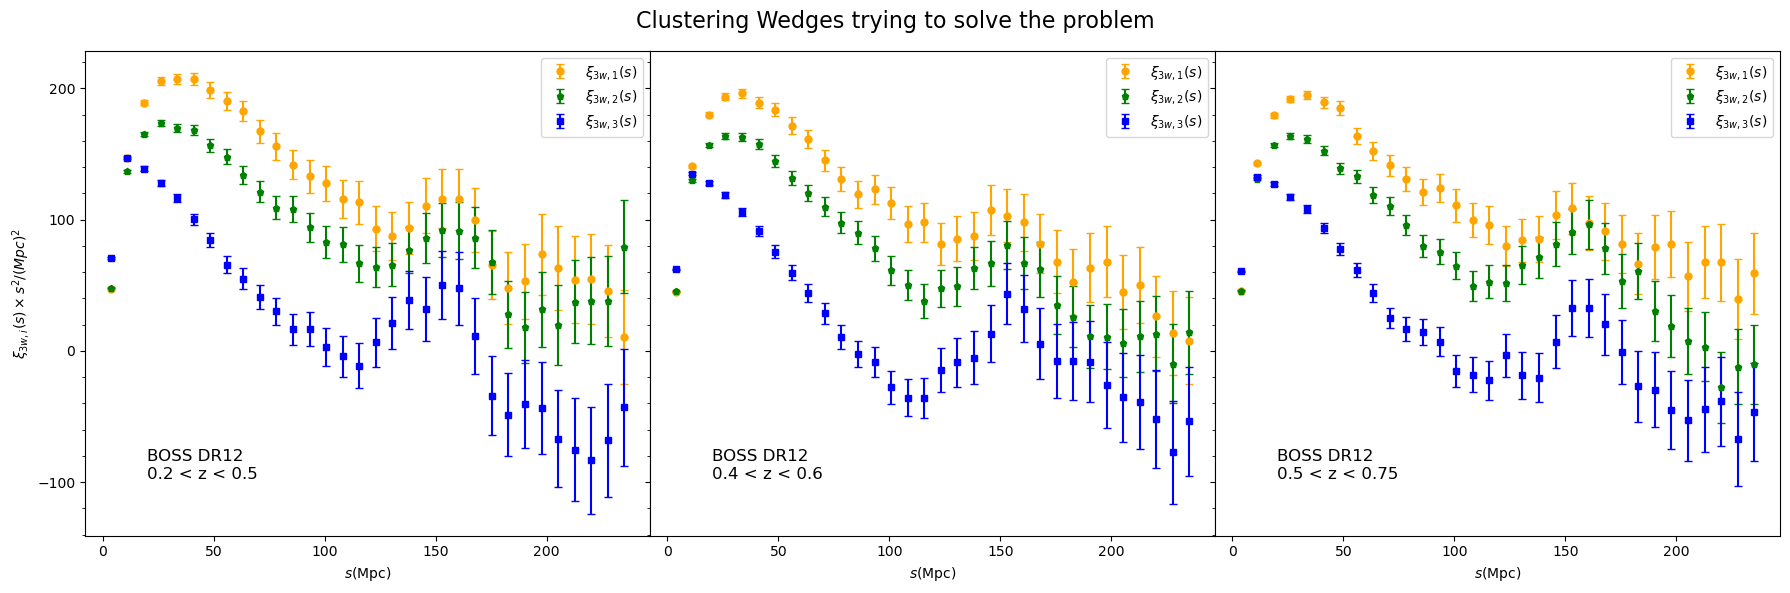

In [16]:
# Trying to solve the value of y-axis problem
# Wedges plot
# Layout of 1 row and 3 columns for the plot
fig1, axs1 = plt.subplots(1, 3, figsize=(18, 6), sharey=True, gridspec_kw={'wspace': 0, 'width_ratios': [1, 1, 1]})
# sharey=True allows to share the y-axis among the subplots

# General title
fig1.suptitle("Clustering Wedges trying to solve the problem", fontsize=16)

# Colors, labels and z_ranges
colors = ['orange', 'green', 'blue']
labels = [r'$\xi_{3w,1}(s)$', r'$\xi_{3w,2}(s)$', r'$\xi_{3w,3}(s)$']
z_ranges = ["0.2 < z < 0.5", "0.4 < z < 0.6", "0.5 < z < 0.75"]

# Assuming a value for the reduced Hubble parameter h to convert the x-axis values
h = 0.67

# Iterate over the subplots (one for each redshift range)
for i, ax1 in enumerate(axs1):
    # Plot of the 3 DataFrame for each subplot
    for j in range(3):
        # Obtain the corrspondent DataFrame
        df = dataframes[i * 3 + j]
        
        # Assign data (column 1: x, column 2: y, column 3: error over y)
        x = df.iloc[:, 0]/h
        y = df.iloc[:, 1]*h
        yerr = df.iloc[:, 2]*h
        
        # Plot with error bars
        ax1.errorbar(x, y*x**2, yerr=yerr*x**2, fmt='o' if colors[j] == 'orange' else 's' if colors[j] == 'blue' else 'p', color=colors[j], label=labels[j], markersize=5, capsize=3)


    
    # y-axis
    #ax.set_ylim(-110, 245)  
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(100))
    ax1.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    axs1[0].set_ylabel(r"$\xi_{3w,i}(s) \times s^2/(Mpc)^2$")

    # Major and minor ticks on lower x-axis    
    #ax.set_xlim(15, 165) 
    #ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    #ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax1.set_xlabel(r"$s(\mathrm{Mpc})$")

    # Top axis
    #ax_top = ax.twiny()
    #ax_top.set_xlim(22, 242)
    #ax_top.xaxis.set_major_locator(ticker.MultipleLocator(50))
    #ax_top.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    #ax_top.set_xlabel(r"$s/(\mathrm{Mpc})$")

    # Adding text inside the plot
    ax1.text(20, -75, f"BOSS DR12\n{z_ranges[i]}", fontsize=12, ha='left', va='top', bbox=dict(facecolor='white', alpha=0.))

    # Rimoving spaces between the subplots
    plt.subplots_adjust(wspace=0)

    # Legend
    ax1.legend(loc='upper right')

    plt.tight_layout()
    
    #plt.show()


96 x 96 Covariance Matrix since such are the available points in the 3 wedges


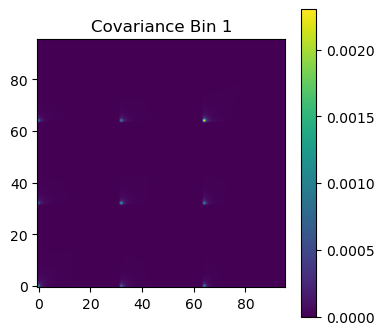

In [9]:
# Reading the covariance matrix for the first redshift bin
file_path_cov_1 = '/home/git/AstroCosmoComputational/Students/Gabriele_Russo/Thesis/Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin1_correlation_function_3wedges_pre_recon_covariance.dat'

df_cov_1 = pd.read_csv(file_path_cov_1, sep='\s+', header=None, skiprows=2)


# Visualizing the Covariance with matplotlib
plt.figure(figsize=(4, 4))
# Setting minimum and maximum values for the colormap
#min = -0.01
#max = 0.01
# Plotting the Covariance matrix
plt.imshow(df_cov_1, origin='lower') 
# **WARNING**: the origin='lower' is used to have the same orientation as in the article plot, but it gives
# the diagonal with respect to the matematical definition of the matrix flipped upside down
plt.colorbar()
plt.title('Covariance Bin 1')
print('96 x 96 Covariance Matrix since such are the available points in the 3 wedges')

In [10]:
# Covarianza effettiva
X_TOT = np.concatenate((x, x, x))
C_bin_1 = pd.DataFrame(np.zeros_like(df_cov_1, dtype=float), columns=df_cov_1.columns, index=df_cov_1.index)

# Iterations over df_cov_1
for i in range(df_cov_1.shape[0]):
    for j in range(df_cov_1.shape[1]):
        if i == j:  # Elemento diagonale
            C_bin_1.iat[i, j] = df_cov_1.iat[i, j] * (X_TOT[i] ** 4) / h**2
        else:  # Elemento fuori diagonale
            C_bin_1.iat[i, j] = df_cov_1.iat[i, j] * X_TOT[i]**2 * X_TOT[j]**2 / h**2


96 x 96 Covariance Matrix since such are the available points in the 3 wedges


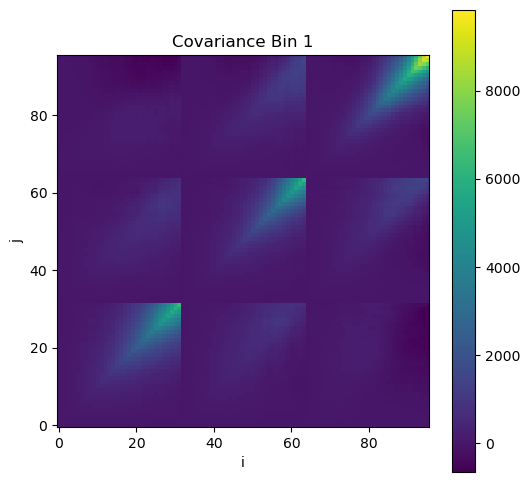

In [11]:
# Visualizing the Covariance with matplotlib
plt.figure(figsize=(6, 6))
# Setting minimum and maximum values for the colormap
#min = -0.01
#max = 0.01
# Plotting the Covariance matrix
plt.imshow(C_bin_1, origin='lower') 
# **WARNING**: the origin='lower' is used to have the same orientation as in the article plot, but it gives
# the diagonal with respect to the matematical definition of the matrix flipped upside down
plt.colorbar()
plt.title('Covariance Bin 1')
plt.xlabel('i')
plt.ylabel('j')
print('96 x 96 Covariance Matrix since such are the available points in the 3 wedges')

96 x 96 Covariance Matrix since such are the available points in the 3 wedges
96 x 96 Covariance Matrix since such are the available points in the 3 wedges


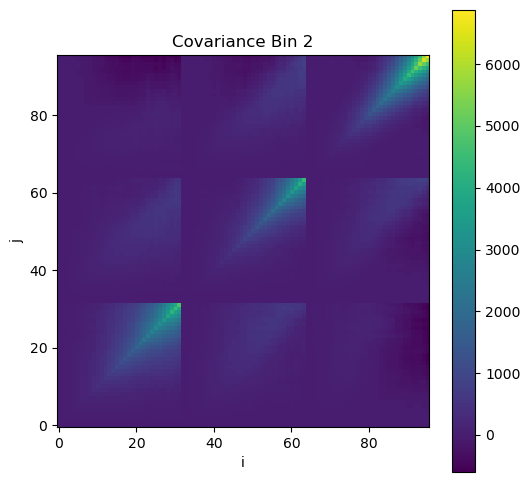

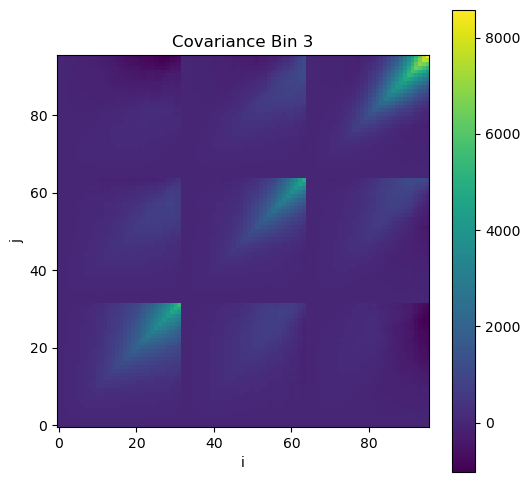

In [12]:
# Reading the covariance matrix for the second and third redshift bin

file_path_cov_2 = '/home/git/AstroCosmoComputational/Students/Gabriele_Russo/Thesis/Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin2_correlation_function_3wedges_pre_recon_covariance.dat'
file_path_cov_3 = '/home/git/AstroCosmoComputational/Students/Gabriele_Russo/Thesis/Sanchez_etal_2016a_COMBINEDDR12_fullshape_wedges/Sanchez_2016a_COMBINEDDR12/Sanchez_2016a_COMBINEDDR12_Bin3_correlation_function_3wedges_pre_recon_covariance.dat'

df_cov_2 = pd.read_csv(file_path_cov_2, sep='\s+', header=None, skiprows=2)
df_cov_3 = pd.read_csv(file_path_cov_3, sep='\s+', header=None, skiprows=2)

# Covarianza effettiva
C_bin_2 = pd.DataFrame(np.zeros_like(df_cov_2, dtype=float), columns=df_cov_2.columns, index=df_cov_2.index)
C_bin_3 = pd.DataFrame(np.zeros_like(df_cov_3, dtype=float), columns=df_cov_3.columns, index=df_cov_3.index)

# Iterations over df_cov_2
for i in range(df_cov_2.shape[0]):
    for j in range(df_cov_2.shape[1]):
        if i == j:  # Elemento diagonale
            C_bin_2.iat[i, j] = df_cov_2.iat[i, j] * (X_TOT[i] ** 4) / h**2
        else:  # Elemento fuori diagonale
            C_bin_2.iat[i, j] = df_cov_2.iat[i, j] * X_TOT[i]**2 * X_TOT[j]**2 / h**2

# Iterations over df_cov_3
for i in range(df_cov_3.shape[0]):
    for j in range(df_cov_3.shape[1]):
        if i == j:  # Elemento diagonale
            C_bin_3.iat[i, j] = df_cov_3.iat[i, j] * (X_TOT[i] ** 4) / h**2
        else:  # Elemento fuori diagonale
            C_bin_3.iat[i, j] = df_cov_3.iat[i, j] * X_TOT[i]**2 * X_TOT[j]**2 / h**2

# Visualizing the Covariance with matplotlib
plt.figure(figsize=(6, 6))
# Setting minimum and maximum values for the colormap
#min = -0.01
#max = 0.01
# Plotting the Covariance matrix
plt.imshow(C_bin_2, origin='lower')
# **WARNING**: the origin='lower' is used to have the same orientation as in the article plot, but it gives
# the diagonal with respect to the matematical definition of the matrix flipped upside down
plt.colorbar()
plt.title('Covariance Bin 2')
plt.xlabel('i')
plt.ylabel('j')
print('96 x 96 Covariance Matrix since such are the available points in the 3 wedges')

# Visualizing the Covariance with matplotlib
plt.figure(figsize=(6, 6))
# Setting minimum and maximum values for the colormap
#min = -0.01
#max = 0.01
# Plotting the Covariance matrix
plt.imshow(C_bin_3, origin='lower')
# **WARNING**: the origin='lower' is used to have the same orientation as in the article plot, but it gives
# the diagonal with respect to the matematical definition of the matrix flipped upside down
plt.colorbar()
plt.title('Covariance Bin 3')
plt.xlabel('i')
plt.ylabel('j')
print('96 x 96 Covariance Matrix since such are the available points in the 3 wedges')




<Figure size 600x600 with 0 Axes>

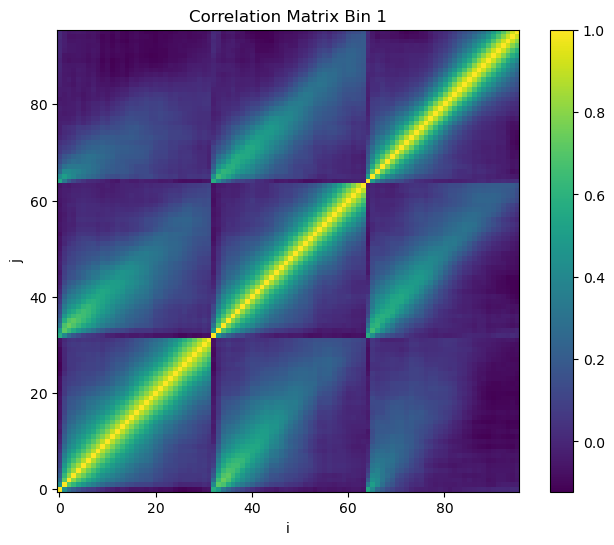

In [13]:
# Plotting the correlation matrix for bin 1
std_dev_1 = np.sqrt(np.diag(df_cov_1))
plt.figure(figsize=(6, 6))

correlation_matrix = df_cov_1 / np.outer(std_dev_1, std_dev_1)


plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, origin='lower')
plt.title('Correlation Matrix Bin 1')
plt.colorbar()

plt.xlabel('i')
plt.ylabel('j')
plt.show()


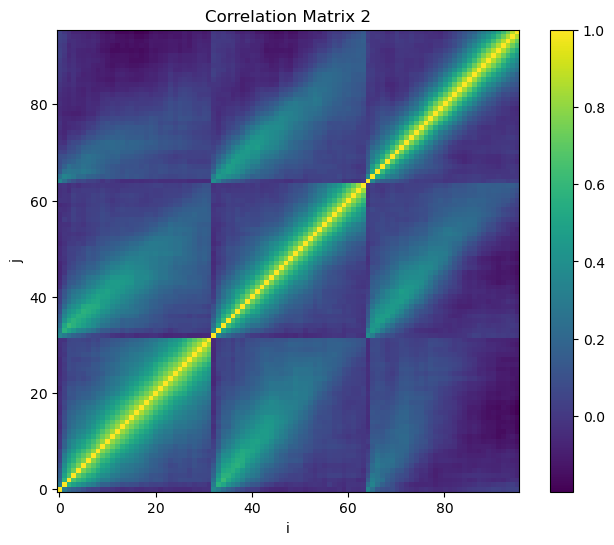

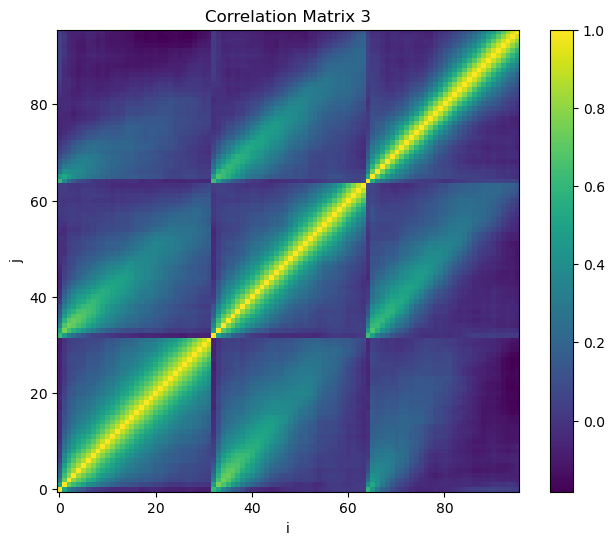

In [14]:
# Plotting for bin 2 and 3
std_dev_2 = np.sqrt(np.diag(df_cov_2))
std_dev_3 = np.sqrt(np.diag(df_cov_3))

correlation_matrix_2 = df_cov_2 / np.outer(std_dev_2, std_dev_2)
correlation_matrix_3 = df_cov_3 / np.outer(std_dev_3, std_dev_3)

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix_2, origin='lower')
plt.title('Correlation Matrix 2')
plt.colorbar()

plt.xlabel('i')
plt.ylabel('j')

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix_3, origin='lower')
plt.title('Correlation Matrix 3')
plt.colorbar()

plt.xlabel('i')
plt.ylabel('j')

plt.show()